In [1]:
!pip install yfinance pandas matplotlib numpy

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 1. 下载数据 (对应书中日期：2001-11-26 至 2007-11-14)
# 注意：为了计算第一天的收益率，我们需要提前一天的价格
start_date = "2001-11-26"
end_date = "2007-11-15"

ige = yf.download("IGE", start=start_date, end=end_date)
spy = yf.download("SPY", start=start_date, end=end_date)

/tmp/ipykernel_301289/545088644.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ige = yf.download("IGE", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_301289/545088644.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [7]:
ige

Price,Close,High,Low,Open,Volume
Ticker,IGE,IGE,IGE,IGE,IGE
Date,,,,,
2001-11-26,9.190161,9.190161,9.190161,9.190161,0
2001-11-27,9.190161,9.190161,9.190161,9.190161,0
2001-11-28,9.190161,9.190161,9.190161,9.190161,0
2001-11-29,9.190161,9.190161,9.190161,9.190161,0
2001-11-30,9.221468,9.221468,9.221468,9.221468,600
...,...,...,...,...,...
2007-11-08,29.094564,29.482897,28.579694,29.122925,316800
2007-11-09,28.584051,29.037838,28.416065,29.037838,162000


In [8]:
spy

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2001-11-26,74.484680,74.748101,73.932132,74.369031,13726000
2001-11-27,74.163414,75.107885,73.302466,74.285490,19261400
2001-11-28,72.820580,73.996350,72.762757,73.720076,20195500
2001-11-29,73.803658,73.835779,72.602186,73.026236,16354700
2001-11-30,73.276817,73.829365,73.257538,73.501690,13680300
...,...,...,...,...,...
2007-11-08,104.818794,105.702012,103.330136,105.409986,374509900
2007-11-09,103.379990,105.089452,103.201920,103.771745,277745100


In [11]:
# 2. 提取复权收盘价并计算日收益率
ige_ret = ige['Close']['IGE'].pct_change().dropna()
spy_ret = spy['Close']['SPY'].pct_change().dropna()

# 确保两个序列日期对齐
returns = pd.concat([ige_ret, spy_ret], axis=1).dropna()
returns.columns = ['IGE', 'SPY']
returns

,IGE,SPY
Date,,
2001-11-27,0.000000,-0.004313
2001-11-28,0.000000,-0.018106
2001-11-29,0.000000,0.013500
2001-11-30,0.003407,-0.007138
2001-12-03,0.000000,-0.005963
...,...,...
2007-11-08,0.006490,-0.005071
2007-11-09,-0.017547,-0.013727
2007-11-12,-0.046863,-0.009922


In [12]:
# 3. 计算 Sharpe Ratio (Long-only IGE)
excess_ret_ige = returns['IGE'] - (0.04 / 252)
sharpe_ige = np.sqrt(252) * excess_ret_ige.mean() / excess_ret_ige.std()
sharpe_ige

np.float64(0.7886051659608982)

In [18]:
# 4. 计算市场中性策略 (Long IGE, Short SPY)
# 策略收益 = (IGE收益 - SPY收益) / 2 (因为使用了2倍资金)
net_ret = (returns['IGE'] - returns['SPY']) / 2
net_ret

Date
2001-11-27    0.002157
2001-11-28    0.009053
2001-11-29   -0.006750
2001-11-30    0.005273
2001-12-03    0.002981
                ...   
2007-11-08    0.005781
2007-11-09   -0.001910
2007-11-12   -0.018471
2007-11-13   -0.005551
2007-11-14    0.002720
Length: 1503, dtype: float64

In [36]:
# 5. 计算累计收益、高水位线和回撤
equity_curve = (1 + net_ret).cumprod()

cum_ret = equity_curve - 1

high_watermark = equity_curve.cummax()
drawdown = (high_watermark - equity_curve) / high_watermark

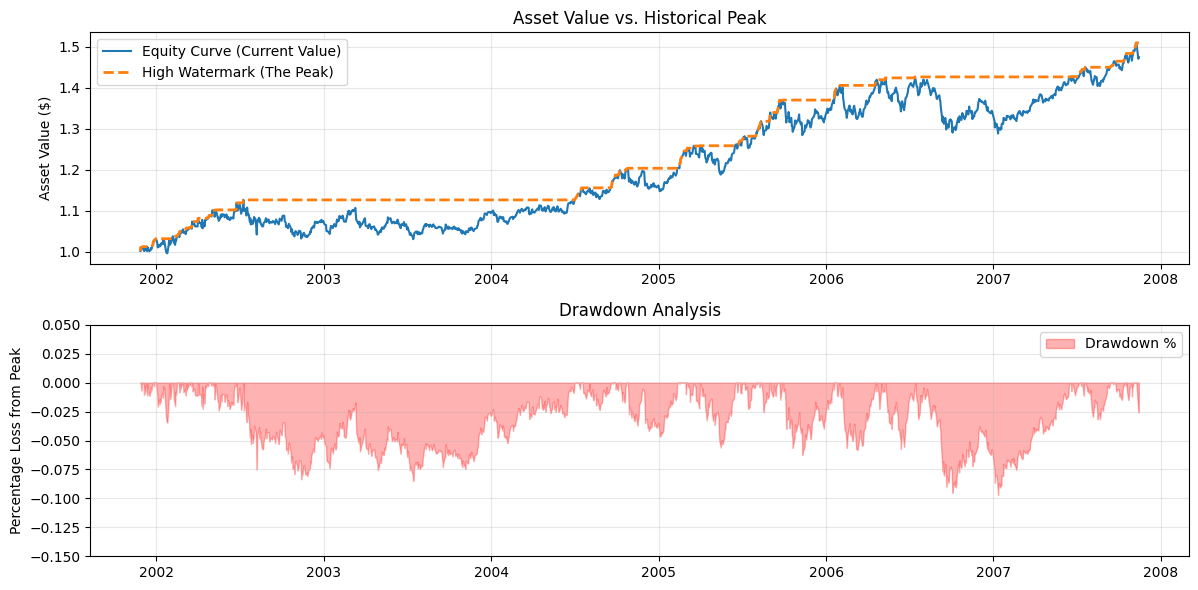

In [37]:
plt.figure(figsize=(12, 6))

# --- 子图 1: 资产净值与高水位线 ---
plt.subplot(2, 1, 1)
plt.plot(equity_curve.index, equity_curve.values, label='Equity Curve (Current Value)', color='#1f77b4', lw=1.5)
plt.plot(high_watermark.index, high_watermark.values, label='High Watermark (The Peak)', color='#ff7f0e', linestyle='--', lw=2)
plt.title('Asset Value vs. Historical Peak', fontsize=12)
plt.ylabel('Asset Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# --- 子图 2: 回撤百分比 (Drawdown) ---
plt.subplot(2, 1, 2)
# 将回撤转为负值显示更直观（表示从高点跌了多少）
plt.fill_between(drawdown.index, 0, -drawdown.values, color='red', alpha=0.3, label='Drawdown %')
plt.title('Drawdown Analysis', fontsize=12)
plt.ylabel('Percentage Loss from Peak')
plt.ylim(-0.15, 0.05) # 根据策略情况调整纵轴
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# 6. 计算最大回撤和最大回撤持续时间
max_dd = drawdown.max()

# 计算持续时间 (Duration)
is_in_dd = drawdown > 0
# 技巧：通过比较当前和前一个状态的变化来分组，计算连续为True的个数
dd_groups = (~is_in_dd).cumsum()
durations = is_in_dd.groupby(dd_groups).cumsum()
max_ddd_value = durations.max()

In [30]:
# --- 输出结果 ---
print(f"--- 策略表现统计 ---")
print(f"IGE 单边持仓 Sharpe Ratio: {sharpe_ige:.4f}")
print(f"市场中性策略最大回撤 (Max DD): {max_dd:.4%}")
print(f"最大回撤持续时间 (Max DDD): {int(max_ddd_value)} 交易日")

--- 策略表现统计 ---
IGE 单边持仓 Sharpe Ratio: 0.7886
市场中性策略最大回撤 (Max DD): 9.6868%
最大回撤持续时间 (Max DDD): 498 交易日


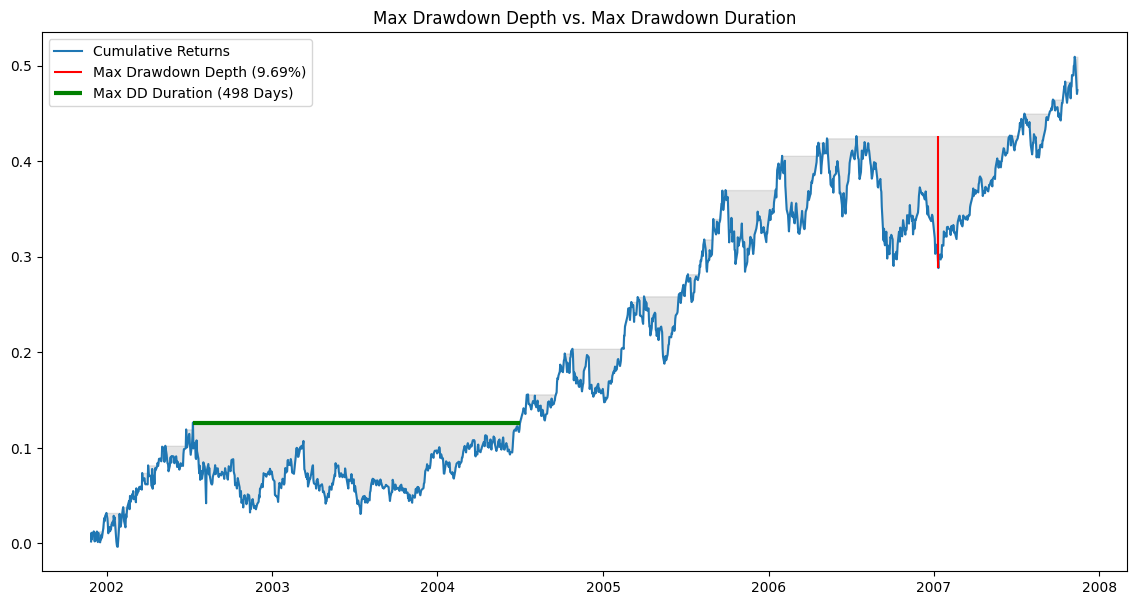

In [38]:
ddd_end_idx = durations.idxmax()

# 找到最长持续时间的起点（该组回撤开始的地方）
# 往回找，直到 drawdown 为 0 的那个点
ddd_start_idx = drawdown[:ddd_end_idx][drawdown[:ddd_end_idx] == 0].index[-1]

# --- 绘图 ---
plt.figure(figsize=(14, 7))
plt.plot(cum_ret, label='Cumulative Returns', color='#1f77b4')
plt.fill_between(cum_ret.index, cum_ret, high_watermark-1, color='gray', alpha=0.2)

# 标注：最大回撤深度 (可能在 A 处)
max_dd_end_idx = drawdown.idxmax()
max_dd_start_idx = equity_curve[:max_dd_end_idx].idxmax()
plt.vlines(x=max_dd_end_idx, ymin=cum_ret[max_dd_end_idx], ymax=cum_ret[max_dd_start_idx], 
           color='red', label=f'Max Drawdown Depth ({max_dd:.2%})')

# 标注：最大回撤持续时间 (可能在 B 处，即耗时最长的平台期)
plt.hlines(y=cum_ret[ddd_start_idx], xmin=ddd_start_idx, xmax=ddd_end_idx, 
           color='green', linewidth=3, label=f'Max DD Duration ({int(max_ddd_value)} Days)')

plt.title('Max Drawdown Depth vs. Max Drawdown Duration')
plt.legend()
plt.show()